In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv("retail_sales_dataset.csv")

In [18]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [19]:
features = df.drop(columns=["Customer ID"])


In [20]:
features.duplicated().sum()

np.int64(0)

In [21]:
features.isnull().sum()

Transaction ID      0
Date                0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [22]:
features = df.select_dtypes(include=['number'])


In [23]:
from sklearn.preprocessing import StandardScaler

# FEATURE SCALING

In [24]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(features)
x_scaled_df = pd.DataFrame(x_scaled, columns=features.columns)
print(x_scaled_df.describe().loc[["mean", "std"]].round(2))

      Transaction ID  Age  Quantity  Price per Unit  Total Amount
mean             0.0 -0.0       0.0             0.0          -0.0
std              1.0  1.0       1.0             1.0           1.0


# PCA REDUCTION

In [25]:
from sklearn.decomposition import PCA

In [33]:
# Create output folder
import os


OUT = "output"
os.makedirs(OUT, exist_ok=True)

# Full PCA
pca_full = PCA()
pca_full.fit(x_scaled)

explained = pca_full.explained_variance_ratio_
cumulative_explained = np.cumsum(explained)

# Explained variance plot
plt.figure(figsize=(8, 5))

plt.bar(
    range(1, len(explained) + 1),
    explained,
    alpha=0.6,
    label="Individual"
)

plt.step(
    range(1, len(explained) + 1),
    cumulative_explained,
    where="mid",
    label="Cumulative"
)

plt.axhline(
    0.8,
    linestyle="--",
    linewidth=1,
    label="80% threshold"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA: Explained Variance by Component")
plt.legend()
plt.tight_layout()

plt.savefig(f"{OUT}/01_pca_variance.png")
plt.close()


# PCA 2D
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(x_scaled)

# PCA 3D
pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(x_scaled)


print(
    f"\nPCA-2D explained variance: "
    f"{pca2.explained_variance_ratio_}, "
    f"total={pca2.explained_variance_ratio_.sum():.3f}"
)

print(
    f"PCA-3D explained variance: "
    f"{pca3.explained_variance_ratio_}, "
    f"total={pca3.explained_variance_ratio_.sum():.3f}"
)


# Component loadings
loadings = pd.DataFrame(
    pca2.components_.T,
    columns=["PC1", "PC2"],
    index=features.columns
)

loadings["abs_PC1"] = loadings["PC1"].abs()

top_pc1 = loadings.sort_values(
    "abs_PC1",
    ascending=False
).head(6)

print("\nTop features driving PC1:")
print(top_pc1[["PC1", "PC2"]])



PCA-2D explained variance: [0.3908516  0.20969281], total=0.601
PCA-3D explained variance: [0.3908516  0.20969281 0.19746848], total=0.798

Top features driving PC1:
                     PC1       PC2
Total Amount    0.698436  0.087850
Price per Unit  0.639262  0.118333
Quantity        0.290412 -0.005334
Transaction ID -0.109567  0.681973
Age            -0.084779  0.716355


# ELBOW METHOD

In [36]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
 
# STEP 5: ELBOW METHOD
# ----------------------------------------------------------------------------
K_range = range(2, 11)
inertias = []
sil_scores = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(x_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(x_scaled, labels))
 
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(list(K_range), inertias, "o-", color="steelblue", label="Inertia (Elbow)")
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("Inertia (Within-Cluster SSE)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
 
ax2 = ax1.twinx()
ax2.plot(list(K_range), sil_scores, "s-", color="darkorange", label="Silhouette Score")
ax2.set_ylabel("Silhouette Score", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")
 
plt.title("Elbow Method (Inertia) vs. Silhouette Score")
fig.tight_layout()
plt.savefig(f"{OUT}/02_elbow_silhouette.png")
plt.close()
 
print("\nK | Inertia | Silhouette")
for k, i, s in zip(K_range, inertias, sil_scores):
    print(f"{k} | {i:.1f} | {s:.4f}")
 
best_k = list(K_range)[int(np.argmax(sil_scores))]
print(f"\nBest K by silhouette score: {best_k}")


K | Inertia | Silhouette
2 | 3408.7 | 0.3163
3 | 2843.4 | 0.2458
4 | 2451.9 | 0.2521
5 | 2160.7 | 0.2393
6 | 1931.9 | 0.2489
7 | 1751.2 | 0.2502
8 | 1616.7 | 0.2577
9 | 1479.4 | 0.2649
10 | 1381.4 | 0.2543

Best K by silhouette score: 2


In [42]:
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(x_scaled)
pca3 = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(x_scaled)

In [43]:
BEST_K = 4
km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(x_scaled)
sil_avg = silhouette_score(x_scaled, cluster_labels)
print(f"Final K={BEST_K} | Average Silhouette Score: {sil_avg:.4f}")
 
df["Cluster"] = cluster_labels
features["Cluster"] = cluster_labels

Final K=4 | Average Silhouette Score: 0.2521


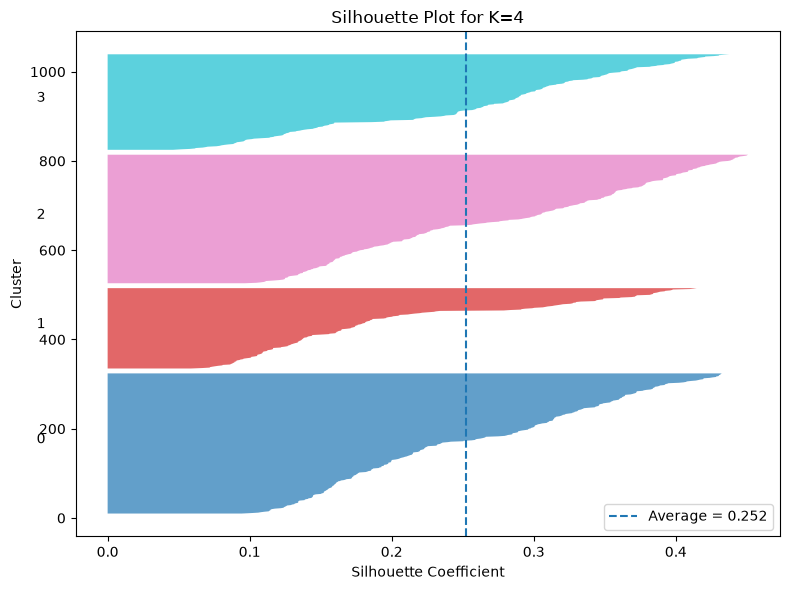

In [50]:
from matplotlib import cm
sample_sil = silhouette_samples(x_scaled, cluster_labels)

fig, ax = plt.subplots(figsize=(8, 6))

y_lower = 10
colors = cm.tab10(np.linspace(0, 1, BEST_K))

for i in range(BEST_K):
    ith = sample_sil[cluster_labels == i]
    ith.sort()

    size_i = len(ith)
    y_upper = y_lower + size_i

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith,
        facecolor=colors[i],
        alpha=0.7
    )

    ax.text(
        -0.05,
        y_lower + 0.5 * size_i,
        str(i)
    )

    y_lower = y_upper + 10

ax.axvline(
    sil_avg,
    linestyle="--",
    label=f"Average = {sil_avg:.3f}"
)

ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")
ax.set_title(f"Silhouette Plot for K={BEST_K}")
ax.legend()

plt.tight_layout()
plt.show()

In [51]:
#----------------------------------------------------------------------------
# STEP 6b: CLUSTERS IN 2D PCA SPACE
# ----------------------------------------------------------------------------
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c=cluster_labels, cmap="tab10", alpha=0.7, s=25)
centers_pca = pca2.transform(scaler.transform(
    pd.DataFrame(km_final.cluster_centers_, columns=feat.columns[:-1]) if False else
    scaler.inverse_transform(km_final.cluster_centers_)
))
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c="black", s=250, marker="X", label="Centroids")
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title(f"Customer Segments in PCA Space (K={BEST_K})")
plt.legend()
cbar = plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.savefig(f"{OUT}/04_pca_clusters_2d.png")
plt.close()

c:\Users\Atif7\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [56]:
# ----------------------------------------------------------------------------
# STEP 6c: 3D PCA VIEW
# ----------------------------------------------------------------------------
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
p = ax.scatter(X_pca3[:, 0], X_pca3[:, 1], X_pca3[:, 2], c=cluster_labels, cmap="tab10", alpha=0.7, s=20)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title(f"Customer Segments in 3D PCA Space (K={BEST_K})")
fig.colorbar(p, label="Cluster", shrink=0.6)
plt.tight_layout()
plt.savefig(f"{OUT}/05_pca_clusters_3d.png")
plt.close()

In [58]:
# ----------------------------------------------------------------------------
# STEP 7: CLUSTER PROFILING -> BUSINESS PERSONAS
# ----------------------------------------------------------------------------

# Average numeric values per cluster
profile = (
    df.groupby("Cluster")[
        ["Age", "Quantity", "Price per Unit", "Total Amount"]
    ]
    .mean()
    .round(1)
)

# Number of customers/transactions in each cluster
profile["Count"] = df.groupby("Cluster").size()

# Percentage of total data
profile["Pct"] = (
    profile["Count"] / len(df) * 100
).round(1)

# Gender split per cluster
gender_split = (
    pd.crosstab(
        df["Cluster"],
        df["Gender"],
        normalize="index"
    )
    .round(3) * 100
)

# Category preference per cluster
cat_split = (
    pd.crosstab(
        df["Cluster"],
        df["Product Category"],
        normalize="index"
    )
    .round(3) * 100
)

# Display results
print("\n=== CLUSTER PROFILE (Mean Values) ===")
print(profile)

print("\n=== GENDER SPLIT (%) ===")
print(gender_split)

print("\n=== CATEGORY PREFERENCE (%) ===")
print(cat_split)


=== CLUSTER PROFILE (Mean Values) ===
          Age  Quantity  Price per Unit  Total Amount  Count   Pct
Cluster                                                           
0        41.9       1.5            35.0          52.6    315  31.5
1        42.1       1.5           410.5         603.9    181  18.1
2        41.8       3.6            35.5         126.5    289  28.9
3        39.5       3.5           392.1        1365.6    215  21.5

=== GENDER SPLIT (%) ===
Gender   Female  Male
Cluster              
0          47.6  52.4
1          52.5  47.5
2          53.6  46.4
3          51.2  48.8

=== CATEGORY PREFERENCE (%) ===
Product Category  Beauty  Clothing  Electronics
Cluster                                        
0                   29.8      34.0         36.2
1                   30.4      33.7         35.9
2                   31.8      37.4         30.8
3                   30.7      34.9         34.4



=== CLUSTER PROFILE (mean values + percentage) ===
          Age  Quantity  Price per Unit  Total Amount  Count   Pct
Cluster                                                           
0        41.9       1.5            35.0          52.6    315  31.5
1        42.1       1.5           410.5         603.9    181  18.1
2        41.8       3.6            35.5         126.5    289  28.9
3        39.5       3.5           392.1        1365.6    215  21.5

=== GENDER SPLIT (%) ===
Gender   Female  Male
Cluster              
0          47.6  52.4
1          52.5  47.5
2          53.6  46.4
3          51.2  48.8

=== CATEGORY PREFERENCE (%) ===
Product Category  Beauty  Clothing  Electronics
Cluster                                        
0                   29.8      34.0         36.2
1                   30.4      33.7         35.9
2                   31.8      37.4         30.8
3                   30.7      34.9         34.4


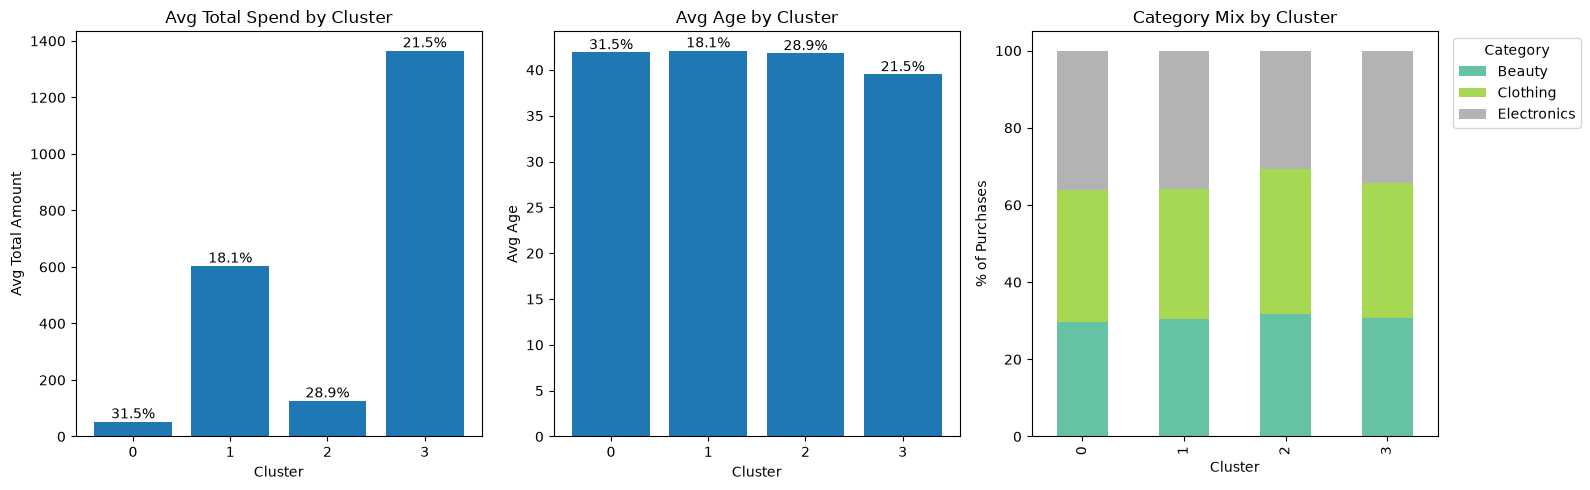


Saved: customers_with_clusters.csv, cluster_profile_summary.csv, cluster_gender_split.csv, cluster_category_split.csv, 06_cluster_profiles_bar.png


In [61]:
# ----------------------------------------------------------------------------
# STEP 7: CLUSTER PROFILING -> BUSINESS PERSONAS
# ----------------------------------------------------------------------------

# Profile columns
profile_cols = [
    "Age",
    "Quantity",
    "Price per Unit",
    "Total Amount"
]

# Mean values for each cluster
profile = (
    df.groupby("Cluster")[profile_cols]
    .mean()
    .round(1)
)

# Cluster size
profile["Count"] = df.groupby("Cluster").size()

# Cluster percentage
profile["Pct"] = (
    profile["Count"] / len(df) * 100
).round(1)


# ----------------------------------------------------------------------------
# Gender split per cluster
# ----------------------------------------------------------------------------

gender_split = (
    pd.crosstab(
        df["Cluster"],
        df["Gender"],
        normalize="index"
    )
    .round(3) * 100
)


# ----------------------------------------------------------------------------
# Category preference per cluster
# ----------------------------------------------------------------------------

cat_split = (
    pd.crosstab(
        df["Cluster"],
        df["Product Category"],
        normalize="index"
    )
    .round(3) * 100
)


# ----------------------------------------------------------------------------
# Print results
# ----------------------------------------------------------------------------

print("\n=== CLUSTER PROFILE (mean values + percentage) ===")
print(profile)

print("\n=== GENDER SPLIT (%) ===")
print(gender_split)

print("\n=== CATEGORY PREFERENCE (%) ===")
print(cat_split)


# ----------------------------------------------------------------------------
# Save profile files
# ----------------------------------------------------------------------------

profile.to_csv(
    f"{OUT}/cluster_profile_summary.csv"
)

gender_split.to_csv(
    f"{OUT}/cluster_gender_split.csv"
)

cat_split.to_csv(
    f"{OUT}/cluster_category_split.csv"
)


# ----------------------------------------------------------------------------
# Combined bar chart
# ----------------------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5)
)


# ----------------------------------------------------------------------------
# Chart 1: Average Total Amount by Cluster
# ----------------------------------------------------------------------------

bars1 = axes[0].bar(
    profile.index.astype(str),
    profile["Total Amount"]
)

axes[0].set_title(
    "Avg Total Spend by Cluster"
)

axes[0].set_ylabel(
    "Avg Total Amount"
)

axes[0].set_xlabel(
    "Cluster"
)

# Add percentage labels
for i, bar in enumerate(bars1):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{profile.iloc[i]['Pct']:.1f}%",
        ha="center",
        va="bottom"
    )


# ----------------------------------------------------------------------------
# Chart 2: Average Age by Cluster
# ----------------------------------------------------------------------------

bars2 = axes[1].bar(
    profile.index.astype(str),
    profile["Age"]
)

axes[1].set_title(
    "Avg Age by Cluster"
)

axes[1].set_ylabel(
    "Avg Age"
)

axes[1].set_xlabel(
    "Cluster"
)

# Add percentage labels
for i, bar in enumerate(bars2):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{profile.iloc[i]['Pct']:.1f}%",
        ha="center",
        va="bottom"
    )


# ----------------------------------------------------------------------------
# Chart 3: Category Mix by Cluster
# ----------------------------------------------------------------------------

cat_split.plot(
    kind="bar",
    stacked=True,
    ax=axes[2],
    colormap="Set2"
)

axes[2].set_title(
    "Category Mix by Cluster"
)

axes[2].set_ylabel(
    "% of Purchases"
)

axes[2].set_xlabel(
    "Cluster"
)

axes[2].legend(
    title="Category",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)


# ----------------------------------------------------------------------------
# Save combined chart
# ----------------------------------------------------------------------------

plt.tight_layout()

plt.savefig(
    f"{OUT}/06_cluster_profiles_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ----------------------------------------------------------------------------
# Save final labeled dataset
# ----------------------------------------------------------------------------

df.to_csv(
    f"{OUT}/customers_with_clusters.csv",
    index=False
)


print(
    "\nSaved: customers_with_clusters.csv, "
    "cluster_profile_summary.csv, "
    "cluster_gender_split.csv, "
    "cluster_category_split.csv, "
    "06_cluster_profiles_bar.png"
)